<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
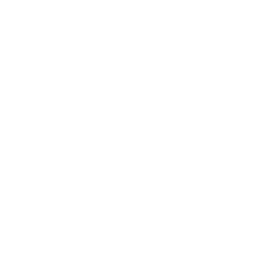
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Diagnoza zakłóceń reaktora chemicznego</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Identyfikacja zmiennych odpowiedzialnych za przekroczenie T2 reaktora podczas zakłócenia &nbsp;|&nbsp; Marzec 2026</p>
</div>
</div>
</div>

## Streszczenie

Reaktor zbiornikowy z mieszaniem ciągłym (CSTR) wpadł w zakłócenie
termiczne, gdy jego zasilanie w chłodziwo uległo degradacji. W normalnej
pracy przepływ chłodziwa, temperatura reaktora i temperatura płaszcza
poruszają się razem wzdłuż jednej osi obciążenia procesu. Budujemy
trójskładnikowy model MVP na 100 obserwacjach normalnej pracy, a
następnie oceniamy wobec niego 100 obserwacji zdarzenia zakłócenia za
pomocą `PROC MVPDIAGNOSE`. Rozkład statystyki T-kwadrat Hotellinga na
wkłady poszczególnych zmiennych izoluje triadę sprzężenia termicznego —
`jacket_temp`, `coolant_flow` i `reactor_temp` — jako zmienne
odpowiedzialne za przekroczenie, wskazując służbom eksploatacyjnym
bezpośrednio na podsystem chłodziwa.


## Źródła danych

| Zbiór danych | Rola | Obserwacje |
|---|---|---|
| `reactor_normal` | Dane treningowe normalnej pracy dla modelu MVP | 100 |
| `reactor_upset` | Obserwacje zdarzenia zakłócenia oceniane wobec modelu | 100 |

Pięć mierzonych zmiennych to `reactor_temp` (°C), `coolant_flow`
(l/min), `jacket_temp` (°C), `feed_conc` (g/l) oraz `pressure` (bar).
Oba zbiory danych są symulowane na podstawie wspólnego ukrytego
*obciążenia procesu*, dzięki czemu dane normalne mają tę samą strukturę
korelacji, jaką wykazuje rzeczywisty CSTR; zakłócenie wprowadza utratę
chłodziwa, która przełamuje tę strukturę.


## Krok 1 — Trening modelu MVP dla normalnej pracy

Normalna praca jest sterowana ukrytym obciążeniem procesu: wyższe
obciążenie obniża przepływ chłodziwa, jednocześnie podnosząc
temperaturę reaktora i płaszcza. `PROC MVPMODEL` wyodrębnia trzy główne
składowe ze 100 obserwacji normalnej pracy i utrwala je za pomocą
`OUTMODEL=`, aby krok diagnozy mógł oceniać nowe dane wobec tego samego
odniesienia.


In [1]:
DANE reactor_normal;
  CALL streaminit(7);
  ETYKIETA reactor_temp = "Temperatura reaktora"
        coolant_flow = "Przepływ chłodziwa"
        jacket_temp  = "Temperatura płaszcza"
        feed_conc    = "Stężenie surowca"
        pressure     = "Ciśnienie";
  POWTÓRZ t = 1 TO 100;
    load = rand('normal', 0, 1);                 /* ukryte obciążenie procesu */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5);
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6);
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4);
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    WYJŚCIE;
  KONIEC;
WYKONAJ;

PROCEDURA mvpmodel DANE=reactor_normal outmodel=reactor_model;
  ZMIENNA reactor_temp coolant_flow jacket_temp feed_conc pressure;
  ncomp=3;
WYKONAJ;



                    The MVPMODEL Procedure

  Data Set:          reactor_normal
  Number of Variables: 5
  Missing Value Handling: Exclude
  Number of Observations Read: 100
  Number of Observations Used: 100
  Number of Principal Components: 3

  Correlation Matrix
         Temperatura reaktoraPrzepływ chłodziwaTemperatura płaszczaStężenie surowca Ciśnienie
  Temperatura reaktora    1.0000   -0.9611    0.9530   -0.0726    0.9662
  Przepływ chłodziwa   -0.9611    1.0000   -0.9636    0.0281   -0.9712
  Temperatura płaszcza    0.9530   -0.9636    1.0000    0.0008    0.9720
  Stężenie surowca   -0.0726    0.0281    0.0008    1.0000   -0.0326
  Ciśnienie    0.9662   -0.9712    0.9720   -0.0326    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 3.89511286  2.89376076    0.7790    0.7790
    2 1.00135210  0.95664889    0.2003    0.9793
    3 0.04470321                0.0089    0.9882




NOTE: DATA reactor_normal


NOTE: Wrote reactor_normal (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


## Krok 2 — Ocena zdarzenia zakłócenia i rozkład *T*-kwadrat

Zakłócenie obniża przepływ chłodziwa o około 12 l/min, podczas gdy
temperatura reaktora i płaszcza rosną — normalne sprzężenie
chłodziwo/temperatura zostaje przełamane. `PROC MVPDIAGNOSE` ocenia
każdą obserwację zakłócenia wobec modelu odniesienia, zapisując
znormalizowane wyniki i reszty do `OUT=` oraz wkłady poszczególnych
zmiennych w statystykę *T*-kwadrat do `OUTCONTRIB=`. Każda obserwacja
znajduje się daleko poza granicą kontrolną, potwierdzając trwałe
odchylenie wielowymiarowe, a nie odosobniony szum.


In [2]:
DANE reactor_upset;
  CALL streaminit(101);
  ETYKIETA reactor_temp = "Temperatura reaktora"
        coolant_flow = "Przepływ chłodziwa"
        jacket_temp  = "Temperatura płaszcza"
        feed_conc    = "Stężenie surowca"
        pressure     = "Ciśnienie";
  POWTÓRZ t = 1 TO 100;
    load = rand('normal', 0, 1);
    /* Pompa chłodziwa ulega awarii: przepływ spada, temperatury rosną bez kontroli */
    reactor_temp = 85.0 + 2.5*load + rand('normal', 0, 0.5) + 8.0;
    coolant_flow = 45.0 - 3.0*load + rand('normal', 0, 0.6) - 12.0;
    jacket_temp  = 22.0 + 1.8*load + rand('normal', 0, 0.4) + 5.0;
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*load + rand('normal', 0, 0.05);
    obs_time = t;
    WYJŚCIE;
  KONIEC;
WYKONAJ;

PROCEDURA mvpdiagnose DANE=reactor_upset MODEL=reactor_model
                 out=reactor_scores;
  ZMIENNA reactor_temp coolant_flow jacket_temp feed_conc pressure;
  id obs_time;
  outcontrib=reactor_contrib;
WYKONAJ;



                    The MVPDIAGNOSE Procedure

  Variables:           5
  Observations:        100
  T-squared limit:     14.8750
  Out-of-control:      100
  Variables Diagnosed: Temperatura reaktora, Przepływ chłodziwa, Temperatura płaszcza, Stężenie surowca, Ciśnienie

  Out-of-control observations:
    Obs 1: T2 = 2090.8063
    Obs 2: T2 = 999.7924
    Obs 3: T2 = 1527.3324
    Obs 4: T2 = 2991.6777
    Obs 5: T2 = 3777.1420
    Obs 6: T2 = 1902.6525
    Obs 7: T2 = 3769.1715
    Obs 8: T2 = 2615.9714
    Obs 9: T2 = 1143.3295
    Obs 10: T2 = 3332.9549
    Obs 11: T2 = 2752.9890
    Obs 12: T2 = 2494.0743
    Obs 13: T2 = 3270.5544
    Obs 14: T2 = 5566.4499
    Obs 15: T2 = 3268.5867
    Obs 16: T2 = 3393.2374
    Obs 17: T2 = 1646.0731
    Obs 18: T2 = 2328.4410
    Obs 19: T2 = 1748.7747
    Obs 20: T2 = 3117.7899
    ... and 80 more





NOTE: DATA reactor_upset


NOTE: Wrote reactor_upset (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPDIAGNOSE
NOTE: PROC MVPDIAGNOSE statement used.


## Krok 3 — Uszeregowanie średnich wkładów

`OUTCONTRIB=` zapisuje jeden wiersz na każdą ocenioną obserwację z
kolumną `<zmienna>_CONTRIB` dla każdej zmiennej procesowej. Uśrednienie
tych kolumn daje średni wkład każdej zmiennej w zakłócenie; transpozycja
przekształca jednowierszowe podsumowanie w przejrzystą tabelę
zmienna/wartość, która porządkuje czynniki usterki.


In [3]:
PROCEDURA ŚREDNIE DANE=reactor_contrib mean NOPRINT;
  ZMIENNA reactor_temp_contrib coolant_flow_contrib jacket_temp_contrib
      feed_conc_contrib pressure_contrib;
  WYJŚCIE out=contrib_means
    mean=mc_reactor_temp mc_coolant_flow mc_jacket_temp
         mc_feed_conc mc_pressure;
WYKONAJ;

PROCEDURA TRANSPOSE DANE=contrib_means out=contrib_long name=metric;
  ZMIENNA mc_reactor_temp mc_coolant_flow mc_jacket_temp
      mc_feed_conc mc_pressure;
WYKONAJ;

/* Dołączenie czytelnych nazw zmiennych i wartości średniego wkładu */
DANE contrib_ranked;
  USTAW contrib_long;
  DŁUGOŚĆ variable $24;
  JEŚLI      metric = 'mc_reactor_temp' WTEDY variable = 'Temperatura reaktora';
  PRZECIWNIE JEŚLI metric = 'mc_coolant_flow' WTEDY variable = 'Przepływ chłodziwa';
  PRZECIWNIE JEŚLI metric = 'mc_jacket_temp'  WTEDY variable = 'Temperatura płaszcza';
  PRZECIWNIE JEŚLI metric = 'mc_feed_conc'    WTEDY variable = 'Stężenie surowca';
  PRZECIWNIE JEŚLI metric = 'mc_pressure'     WTEDY variable = 'Ciśnienie';
  mean_contrib = col1;
  ZACHOWAJ variable mean_contrib;
WYKONAJ;

PROCEDURA SORTUJ DANE=contrib_ranked;
  WEDŁUG MALEJĄCO mean_contrib;
WYKONAJ;

PROCEDURA DRUKUJ DANE=contrib_ranked noobs ETYKIETA;
  ZMIENNA variable mean_contrib;
  ETYKIETA variable="Zmienna procesowa" mean_contrib="Średni wkład T-kwadrat";
WYKONAJ;



    Zmienna procesowa    Średni wkład T-kwadrat
---------------------  ------------------------
Temperatura płaszcza              4177.66720283
Przepływ chłodziwa                2882.19501987
Temperatura reaktora              1602.04200377
Ciśnienie                          280.73140863
Stężenie surowca                    61.43535437




NOTE: PROC MEANS
NOTE: Output dataset contrib_means has 1 observations and 7 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC TRANSPOSE data=contrib_means

NOTE: Created 5 rows.
NOTE: Output written to ./work/02098aa2-b4e3-4285-a8a1-b055b679cf03/contrib_long.avro.
NOTE: DATA contrib_ranked


NOTE: Read 5 rows from contrib_long.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=contrib_ranked

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from contrib_ranked.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=contrib_ranked

NOTE: PROC PRINT completed: 5 observations printed, 2 variables


## Krok 4 — Wykres wkładów

Wykres wkładów czyni diagnozę natychmiastową: triada sprzężona
termicznie — `jacket_temp`, `coolant_flow` i `reactor_temp` — dominuje
nad `feed_conc` i `pressure`, które ledwie się zaznaczają. Trzy
dominujące słupki to dokładnie zmienne powiązane pętlą chłodziwa, więc
usterka jest jednoznacznie termiczna, a nie problemem surowca czy
ciśnienia.



NOTE: PROC SGPLOT data=contrib_ranked

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


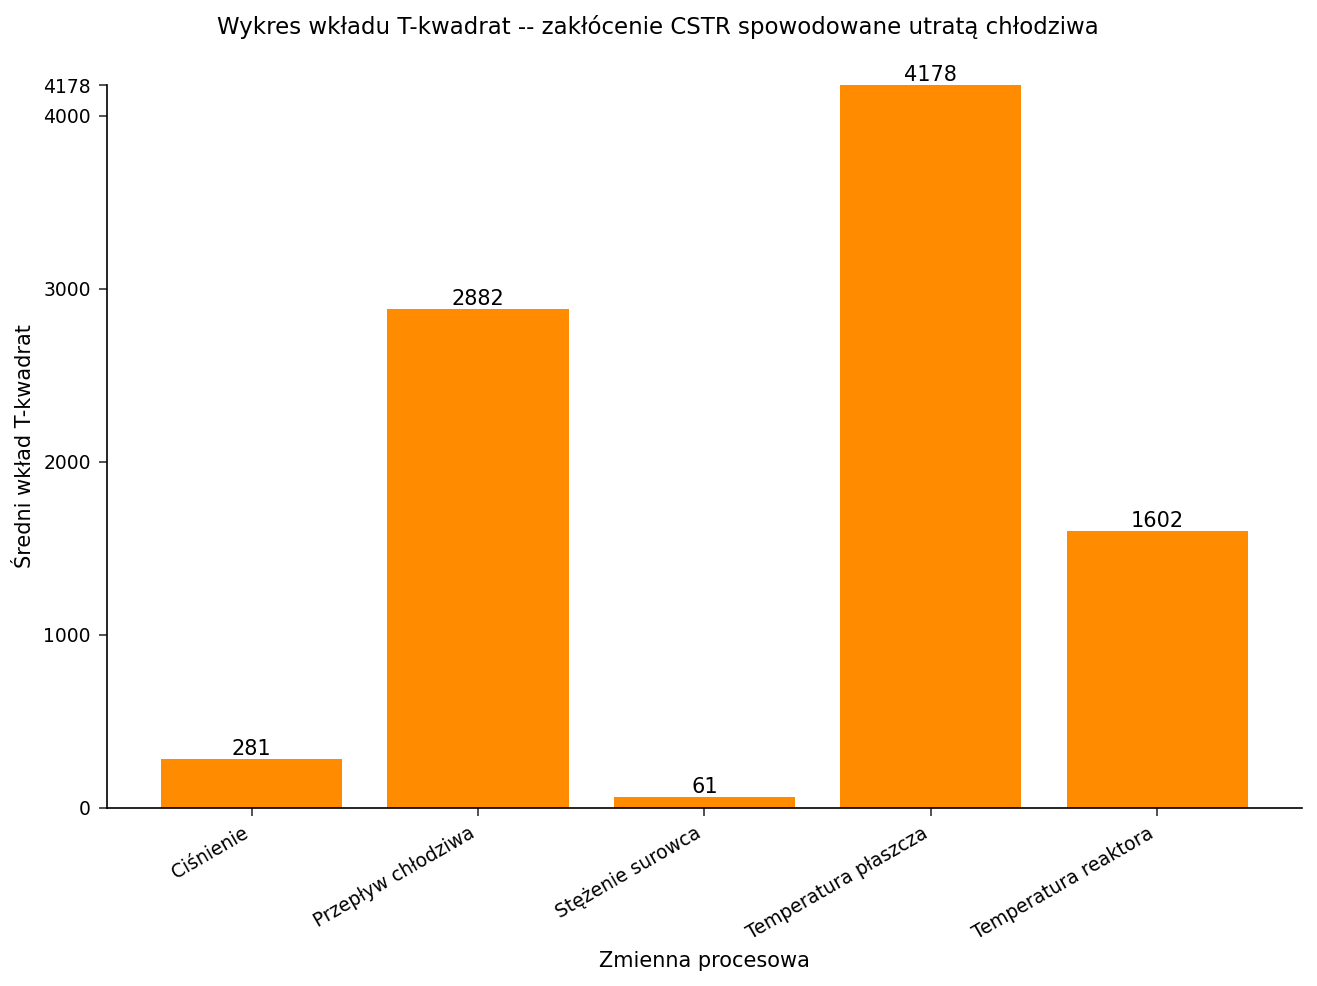

In [4]:
PROCEDURA SGPLOT DANE=contrib_ranked;
  VBAR variable / RESPONSE=mean_contrib
                  fillattrs=(color=darkorange)
                  DATALABEL;
  XAXIS ETYKIETA='Zmienna procesowa';
  YAXIS ETYKIETA='Średni wkład T-kwadrat';
  TYTUŁ 'Wykres wkładu T-kwadrat -- zakłócenie CSTR spowodowane utratą chłodziwa';
WYKONAJ;


## Krok 5 — Oś czasu kontrolna T-kwadrat

Wykreślenie *T*-kwadrat każdej obserwacji względem granicy kontrolnej
modelu pokazuje, że odchylenie jest ciągłe: każda obserwacja zakłócenia
znajduje się o rzędy wielkości powyżej linii odniesienia granicy. W
badanym oknie nie ma powrotu do normy, co jest zgodne z usterką
sprzętową utrzymującą się aż do serwisowania podsystemu chłodziwa.



NOTE: PROC SGPLOT data=reactor_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


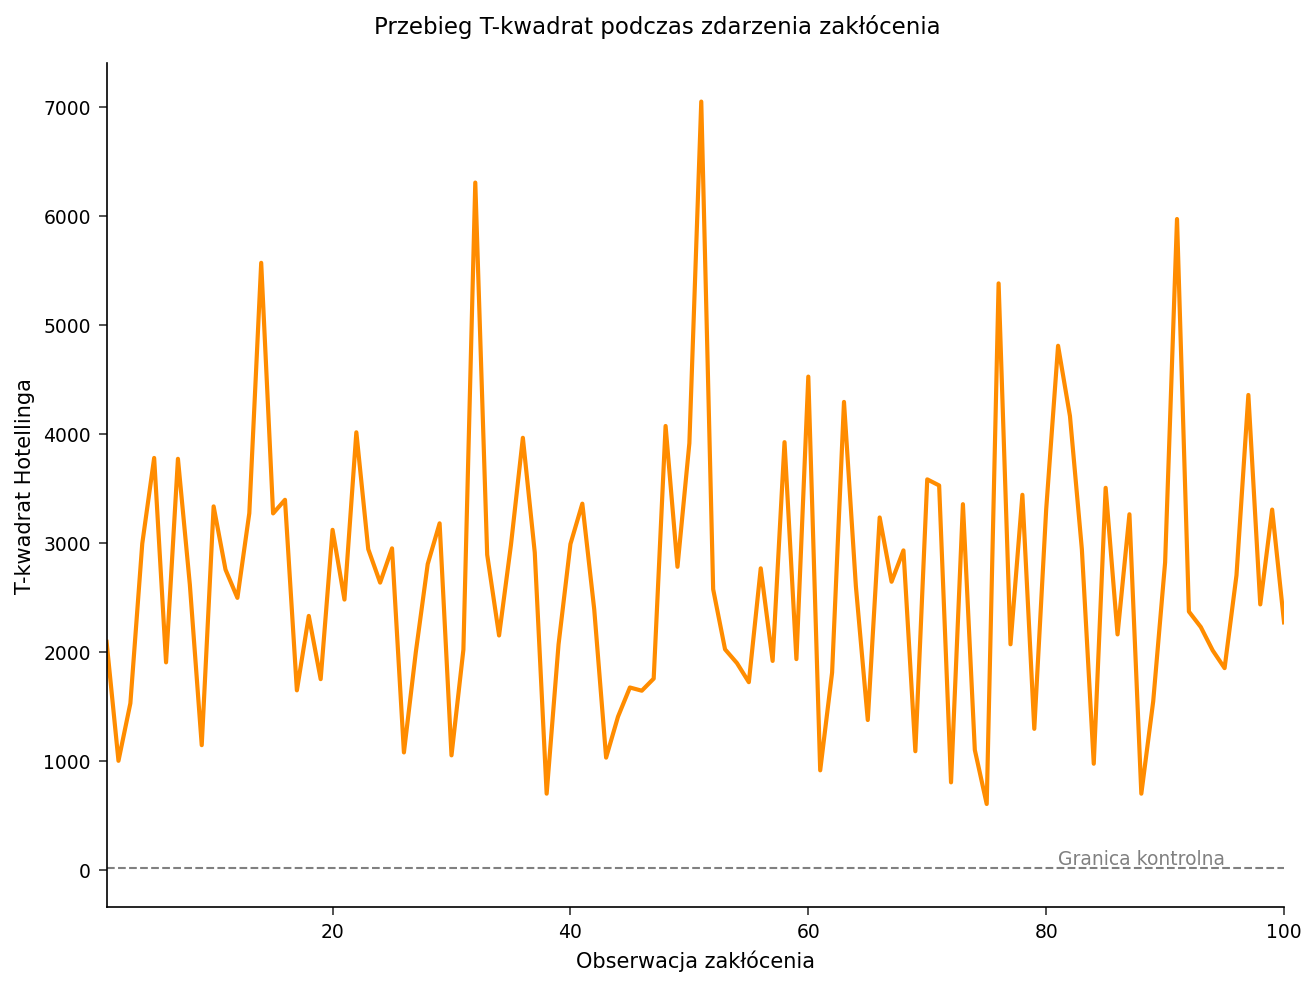

In [5]:
PROCEDURA SGPLOT DANE=reactor_scores;
  SERIES x=_OBS y=_TSQUARED / LINEATTRS=(color=darkorange thickness=2);
  REFLINE 14.87 / AXIS=y
                  ETYKIETA='Granica kontrolna'
                  LINEATTRS=(pattern=dash color=gray);
  XAXIS ETYKIETA='Obserwacja zakłócenia';
  YAXIS ETYKIETA='T-kwadrat Hotellinga';
  TYTUŁ 'Przebieg T-kwadrat podczas zdarzenia zakłócenia';
WYKONAJ;


## Ustalenia i działania naprawcze

- **Główne czynniki**: `jacket_temp`, `coolant_flow` i `reactor_temp`
  łącznie odpowiadają praktycznie za cały sygnał *T*-kwadrat; ich
  średnie wkłady są o dwa do trzech rzędów wielkości wyższe niż
  `feed_conc` i `pressure`.
- **Przyczyna źródłowa**: utrata zasilania w chłodziwo. `coolant_flow`
  jest jedyną *manipulowaną* zmienną z tej trójki — wzrosty temperatury
  są następstwem utraty chłodzenia, więc usterką wymagającą działania
  jest podsystem chłodziwa.
- **Status kontroli**: wszystkie 100 obserwacji zakłócenia przekracza
  granicę *T*-kwadrat, co wskazuje na trwałe odchylenie, a nie
  przejściowy skok.
- **Działanie naprawcze**: sprawdzić i odbudować pompę chłodziwa; dodać
  redundantny nadajnik przepływu chłodziwa, aby przyszła utrata
  zasilania była wykrywana przez alarmowanie jednowymiarowe, zanim
  rozprzestrzeni się na pętlę temperatury.


## Eksport uszeregowanych wkładów

Uszeregowana tabela wkładów jest zapisywana do CSV na potrzeby raportu
poawaryjnego i dalszych dashboardów.


In [6]:
PROCEDURA EKSPORTUJ DANE=contrib_ranked
            OUTFILE='reactor_upset_contributions.csv'
            DBMS=csv REPLACE;
WYKONAJ;



NOTE: PROC EXPORT data=contrib_ranked outfile=reactor_upset_contributions.csv

NOTE: Exported 5 rows to reactor_upset_contributions.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>